# Third-order perturbation you can trust: exact oracles, live Dynare and a blind spot

**When a DSGE model is solved to third order, which coefficients can we trust, and how would we know if one were wrong?**

A third-order solution adds risk to the decision rules: a constant precautionary shift at second order, and responses that change with the level of risk at third order. Those terms come out of a chain of tensor equations, and they are easy to get wrong without any simulated path showing it. This notebook checks puremacro's third-order solver against two models with closed-form solutions and against live Dynare runs, then asks what the checked solution says.

| Replication card | |
|---|---|
| Results checked | Every decision-rule tensor up to third order, the pruned simulated paths and their sample moments, and the exact moments of the pruned solution |
| Oracles | Closed forms (a claim to a cubic payoff; Brock and Mirman's growth model), Dynare 7.0 run in MATLAB R2026a on five models at orders 2 and 3, and Dynare 8's pruned moments and long simulations on six models, all frozen with SHA-256 hashes; no reference value was computed by puremacro |
| Data | None; model calibrations only |
| Solver tested | `load_mod(..., order=3)`, which returns the pruned solution of Andreasen, Fernández-Villaverde and Rubio-Ramírez (2018) |
| Acceptance | Relative error below 1e-12 against the closed forms; the fixtures' own tolerance against Dynare (absolute 1e-10, relative 1e-9) |
| Verdict | Printed by the scorecard at the end, from the computed errors |

## The method in math

Dynare's perturbation writes each variable as a function of the lagged states $\hat x$, the shocks $u$ and a scale $\sigma$ on the shocks, and expands it around the deterministic steady state:
$$y=y^*+g_x\hat x+g_u u+\tfrac12\left(g_{xx}\hat x^{\otimes2}+2g_{xu}\,\hat x\otimes u+g_{uu}u^{\otimes2}+g_{\sigma\sigma}\sigma^2\right)+\tfrac16\left(g_{xxx}\hat x^{\otimes3}+3g_{xxu}\,\hat x^{\otimes2}\otimes u+3g_{xuu}\,\hat x\otimes u^{\otimes2}+g_{uuu}u^{\otimes3}\right)+\tfrac12\left(g_{x\sigma\sigma}\hat x+g_{u\sigma\sigma}u\right)\sigma^2 .$$
The first-order terms are certainty equivalent. Risk enters through $g_{\sigma\sigma}$, a constant shift, and through $g_{x\sigma\sigma}$ and $g_{u\sigma\sigma}$, which make the response to states and shocks depend on how much risk there is. Pruning simulates the first-, second- and third-order parts separately so that paths stay stable.

## Intuition

**Intuition.** A path that matches is weak evidence that a tensor is right. Every simulated observation contracts a tensor with a product of states and shocks, and whole families of wrong tensors give the same contraction. The strong checks are two. Compare every tensor entry with a reference, and use a model whose tensors are known exactly. The risk terms deserve the most attention: they were 25% too large in one closed-form model before release 4.3.0, and a separate mixed-derivative error in the RBC model survived path comparisons until live Dynare tensors exposed it.

## Worked code

Tensors are compared entry by entry after aligning columns by state and shock names, because two programs may order states differently.

In [1]:
from pathlib import Path
from itertools import product
from math import prod
import hashlib
import json
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.dsge import load_mod

# A variable with no first-order response (the claim's price) has no first-order variance
# decomposition; theoretical_moments warns about that, and it is expected here.
warnings.filterwarnings("ignore", message="forecast-error variance is zero")

# The index pattern of each unfolded tensor: x runs over states, u over shocks.
AXES = {"ghx": "x", "ghu": "u", "ghxx": "xx", "ghxu": "xu", "ghuu": "uu", "ghs2": "",
        "ghxxx": "xxx", "ghxxu": "xxu", "ghxuu": "xuu", "ghuuu": "uuu", "ghxss": "x", "ghuss": "u"}
RISK_TERMS = ("ghs2", "ghxss", "ghuss")
# The RBC model of Dynare's live check, byte for byte (section 2 verifies its hash).
RBC = ("var y c k a; varexo e;\nparameters alpha beta delta rho; alpha=.33;beta=.99;delta=.025;rho=.9;\n"
       "model;\n1/c=beta/c(+1)*(alpha*exp(a(+1))*k^(alpha-1)+1-delta);\nk=exp(a)*k(-1)^alpha+(1-delta)*k(-1)-c;\n"
       "a=rho*a(-1)+e;\ny=exp(a)*k(-1)^alpha;\nend;\n"
       "initval; y=3.0153277085137282;c=2.3066172319875173;k=28.348419061048435;a=0;end;\n"
       "shocks;var e;stderr .01;end;\n")

checks = []  # one row per checked result


def record(result, measured, bound, verdict):
    checks.append({"result": result, "measured": float(measured), "bound": bound, "verdict": verdict})


def labelled_tensors(sol, states=None, shocks=None, fields=tuple(AXES)):
    """Decision-rule tensors as DataFrames with columns labelled by state and shock names."""
    dr = sol.decision_rules()
    own_x, own_u = list(dr.state_variables), list(dr.shock_names)
    states, shocks = states or own_x, shocks or own_u
    out = {}
    for field in fields:
        axes = AXES[field]
        own = list(product(*(own_x if a == "x" else own_u for a in axes)))
        cols = list(product(*(states if a == "x" else shocks for a in axes)))
        mat = np.asarray(getattr(dr, field)).reshape(len(dr.variable_names), -1)
        out[field] = pd.DataFrame(mat[:, [own.index(c) for c in cols]], index=list(dr.variable_names), columns=cols)
    return dr, out


def claim_to_cube(beta, rho, s):
    """y_t = beta E_t y_{t+1} + x_t^3: the price of a claim to the convex payoff x^3, x an AR(1)."""
    return load_mod(f"var y x; varexo e; parameters beta rho; beta={beta!r}; rho={rho!r};\n"
                    "model; x = rho*x(-1) + e; y = beta*y(+1) + x^3; end;\n"
                    f"initval; x=0; y=0; end;\nshocks; var e; stderr {s!r}; end;\n", order=3)


def cube_closed_form(beta, rho, s):
    """The exact solution y = A x^3 + B x and its third-order tensors."""
    A = 1.0 / (1.0 - beta * rho**3)
    B = 3.0 * beta * A * rho * s**2 / (1.0 - beta * rho)
    return A, B, {"ghxxx": 6 * A * rho**3, "ghxxu": 6 * A * rho**2, "ghxuu": 6 * A * rho, "ghuuu": 6 * A,
                  "ghxss": 2 * B * rho, "ghuss": 2 * B}

### 1. Two models whose third-order solution is known exactly

**A claim to a cubic payoff.** With $x_t=\rho x_{t-1}+e_t$ and $\operatorname{Var}(e)=s^2$, the price $y_t=\beta E_ty_{t+1}+x_t^3$ is exactly $y=Ax^3+Bx$, where $A=1/(1-\beta\rho^3)$ and $B=3\beta A\rho s^2/(1-\beta\rho)$. Every tensor of $y$ follows, including the risk terms $g_{x\sigma\sigma}=2B\rho$ and $g_{u\sigma\sigma}=2B$; this is the benchmark on which the pre-4.3.0 risk terms were 25% too large. The check runs at the calibration of that finding and at eleven random ones.

**Brock and Mirman (1972).** With log utility and full depreciation the policy is exactly $k_t=\alpha\beta e^{a_t}k_{t-1}^\alpha$ and $c_t=(1-\alpha\beta)e^{a_t}k_{t-1}^\alpha$ at any level of risk. Every derivative is a product of powers, and every risk term must be zero.

In [2]:
calibrations = [(0.95, 0.8, 0.1)]  # the calibration of the 19 September 2026 review
rng = np.random.default_rng(2026)
calibrations += [(rng.uniform(0.5, 0.99), rng.uniform(-0.9, 0.95), rng.uniform(0.01, 0.5)) for _ in range(11)]
worst_cube = 0.0
for beta, rho, s in calibrations:
    _, T = labelled_tensors(claim_to_cube(beta, rho, s))
    A, B, exact = cube_closed_form(beta, rho, s)
    for field in AXES:
        target_y = exact.get(field, 0.0)
        target_x = {"ghx": rho, "ghu": 1.0}.get(field, 0.0)
        worst_cube = max(worst_cube, np.max(np.abs(T[field].loc["y"] - target_y)) / max(1.0, abs(target_y)),
                         np.max(np.abs(T[field].loc["x"] - target_x)) / max(1.0, abs(target_x)))
_, T = labelled_tensors(claim_to_cube(*calibrations[0]))
_, _, exact = cube_closed_form(*calibrations[0])
before_fix = {"ghxss": 0.369937695, "ghuss": 0.462422118}  # reported by the review, release 4.2.0
print(pd.DataFrame({"solver": {f: T[f].loc["y"].iloc[0] for f in exact}, "closed form": exact,
                    "before 4.3.0": before_fix}).round(9).to_string(na_rep=""))
print(f"Largest relative error over {len(calibrations)} calibrations: {worst_cube:.1e}")

alpha, beta_bm, rho_bm, s_bm = 0.33, 0.96, 0.9, 0.05
k_ss = (alpha * beta_bm) ** (1.0 / (1.0 - alpha))
c_ss = (1.0 - alpha * beta_bm) * k_ss**alpha
brock_mirman = load_mod(
    f"var c k a; varexo e; parameters alpha beta rho; alpha={alpha!r}; beta={beta_bm!r}; rho={rho_bm!r};\n"
    "model; 1/c = beta/c(+1)*alpha*exp(a(+1))*k^(alpha-1); c + k = exp(a)*k(-1)^alpha; a = rho*a(-1) + e; end;\n"
    f"initval; k={k_ss!r}; c={c_ss!r}; a=0; end;\nshocks; var e; stderr {s_bm!r}; end;\n", order=3)
_, T = labelled_tensors(brock_mirman)
level = {"k": alpha * beta_bm * k_ss**alpha, "c": c_ss}
worst_bm, worst_risk = 0.0, 0.0
for field, axes in AXES.items():
    for var in T[field].index:
        for col, value in T[field].loc[var].items():
            n_k, n_a = col.count("k"), col.count("a")
            if field in RISK_TERMS:
                worst_risk = max(worst_risk, abs(value))
                continue
            if var == "a":   # a = rho a(-1) + e is linear
                target = rho_bm if (field, col) == ("ghx", ("a",)) else 1.0 if field == "ghu" else 0.0
            else:            # level * alpha(alpha-1)...(alpha-n_k+1) k^-n_k * rho^n_a; shock derivatives are 1
                target = level[var] * prod(alpha - m for m in range(n_k)) * k_ss ** (-n_k) * rho_bm**n_a
            worst_bm = max(worst_bm, abs(value - target) / max(1.0, abs(target)))
print(f"Brock-Mirman: largest relative error over every tensor {worst_bm:.1e}; largest risk term {worst_risk:.1e}")
record("Exact oracle: claim to x^3, every tensor, 12 calibrations (relative)", worst_cube, 1e-12, "exact")
record("Exact oracle: Brock-Mirman policy, every tensor (relative)", worst_bm, 1e-12, "exact")
record("Exact oracle: Brock-Mirman risk terms (certainty equivalence)", worst_risk, 1e-14, "exact")
assert worst_cube < 1e-12 and worst_bm < 1e-12 and worst_risk < 1e-14

          solver  closed form  before 4.3.0
ghxxx   5.981308     5.981308              
ghxxu   7.476636     7.476636              
ghxuu   9.345794     9.345794              
ghuuu  11.682243    11.682243              
ghxss   0.295950     0.295950      0.369938
ghuss   0.369938     0.369938      0.462422
Largest relative error over 12 calibrations: 3.3e-16
Brock-Mirman: largest relative error over every tensor 8.9e-16; largest risk term 2.2e-18


### 2. Five models against live Dynare 7.0

The repository freezes Dynare's own decision rules and pruned simulations for five models at orders 2 and 3 in `tests/fixtures/dynare_live`, with a manifest of SHA-256 hashes; no reference value in them was computed by puremacro. Each model is solved again here, every tensor compared after aligning rows and columns by name, and the model simulated on Dynare's 2,500 innovations. The fixtures ship with the repository rather than the package, so in a browser session this section reports that it did not run.

In [3]:
LIVE = repo / "tests" / "fixtures" / "dynare_live"
sha256 = lambda data: hashlib.sha256(data).hexdigest()


def sample_moments(path, burn):
    x = path[burn:]
    d = x - x.mean(axis=0)
    lag = (x[1:] - x[1:].mean(axis=0)).T @ (x[:-1] - x[:-1].mean(axis=0)) / (len(x) - 2)
    return {"mean": x.mean(axis=0), "covariance": d.T @ d / (len(x) - 1), "lag-1 covariance": lag}


dynare = None
if (LIVE / "manifest.json").is_file():
    manifest = json.loads((LIVE / "manifest.json").read_text())
    atol, rtol, burn = manifest["atol"], manifest["rtol"], manifest["burn"]
    rows, bad_hashes = [], 0
    for name, info in manifest["cases"].items():
        files = {"model": LIVE / info["model"], "reference": LIVE / f"{name}.npz",
                 "innovations": LIVE / f"{Path(info['model']).stem}_innovations.csv"}
        bad_hashes += sum(sha256(path.read_bytes()) != info[f"{key}_sha256"] for key, path in files.items())
        sol = load_mod(files["model"].read_text(), order=info["order"])
        with np.load(files["reference"]) as ref:
            variables, states, shocks = (list(ref[k]) for k in ("variable_names", "state_names", "shock_names"))
            fields = list(AXES)[: 6 if info["order"] == 2 else 12]
            dr, T = labelled_tensors(sol, states, shocks, fields)
            tensor_ok = all(np.allclose(T[f].loc[variables].to_numpy(), ref[f], atol=atol, rtol=rtol) for f in fields)
            tensor_err = {f: np.max(np.abs(T[f].loc[variables].to_numpy() - ref[f])) for f in fields}
            ys_err = np.max(np.abs(dr.ys.loc[variables].to_numpy() - ref["ys"]))
            eps = ref["innovations"][:, [shocks.index(u) for u in sol.shock_names]]
            sim = sol.simulate(periods=len(eps), burn=0, shocks=eps)
            path = pd.concat([sim.states, sim.controls], axis=1)[variables].to_numpy() + dr.ys.loc[variables].to_numpy()
            ours, theirs = sample_moments(path, burn), sample_moments(ref["path"], burn)
            rows.append({"case": name, "order": info["order"], "tensors": max(tensor_err.values()),
                         "worst tensor": max(tensor_err, key=tensor_err.get), "steady state": ys_err,
                         "path": np.max(np.abs(path - ref["path"])),
                         "moments": max(np.max(np.abs(ours[k] - theirs[k])) for k in ours),
                         "within tolerance": tensor_ok and np.allclose(path, ref["path"], atol=atol, rtol=rtol)})
    dynare = pd.DataFrame(rows).set_index("case")
    print(dynare.to_string(float_format=lambda v: f"{v:.1e}"))
    same_rbc = sha256(RBC.encode()) == manifest["cases"]["rbc_order3"]["model_sha256"]
    print(f"Fixture hashes that differ from the manifest: {bad_hashes}; the RBC text above is the file Dynare ran: {same_rbc}")
    record("Dynare 7.0: fixture files whose hash differs from the manifest", bad_hashes, 0, "provenance")
    record("Dynare 7.0: largest tensor error, 10 cases", dynare["tensors"].max(), atol, "independent")
    record("Dynare 7.0: largest simulated-path error", dynare["path"].max(), atol, "independent")
    record("Dynare 7.0: largest sample-moment error", dynare["moments"].max(), atol, "independent")
    assert bad_hashes == 0 and same_rbc and dynare["within tolerance"].all()
else:
    print("Not run: tests/fixtures/dynare_live is part of the repository checkout, not of the installed package.")
    for result in ("fixture files whose hash differs from the manifest", "largest tensor error, 10 cases",
                   "largest simulated-path error", "largest sample-moment error"):
        record(f"Dynare 7.0: {result}", np.nan, "not run", "not run")

                             order  tensors worst tensor  steady state    path  moments  within tolerance
case                                                                                                     
correlated_cubic_order2          2  0.0e+00          ghx       0.0e+00 1.4e-17  2.4e-17              True
correlated_cubic_order3          3  8.9e-16        ghxxx       0.0e+00 1.8e-15  1.9e-17              True
nonlinear_multishock_order2      2  5.6e-17          ghx       0.0e+00 5.6e-17  6.9e-18              True
nonlinear_multishock_order3      3  1.1e-15        ghuuu       0.0e+00 5.6e-17  6.2e-17              True
nonlinear_state_order2           2  0.0e+00          ghx       0.0e+00 5.6e-17  2.1e-17              True
nonlinear_state_order3           3  1.1e-15        ghuuu       0.0e+00 5.6e-17  7.6e-17              True
quadratic_feedback_order2        2  4.4e-16         ghxx       0.0e+00 2.2e-16  1.1e-16              True
quadratic_feedback_order3        3  4.4e-16   

### 3. What a path check cannot see

On 20 September 2026 the live check found the RBC tensor $g_{xxu}$ off by 0.0012928883 while every simulated path matched. The error was antisymmetric in the two state indices: it added a value to the (capital, technology) entry and subtracted it from the (technology, capital) entry. Every observation contracts $g_{xxu}$ with $\hat x\otimes\hat x\otimes u$, which is symmetric in those two indices, so the error cancels exactly. The cell below plants that error, and a symmetric one of the same size, in the correct tensor and measures what each does to a simulated path.

In [4]:
rbc = load_mod(RBC, order=3)
dr, T = labelled_tensors(rbc)
states, shocks = list(dr.state_variables), list(dr.shock_names)
cols = list(T["ghxxu"].columns)
i, j = cols.index((states[0], states[1], shocks[0])), cols.index((states[1], states[0], shocks[0]))
size = 0.0012928883
planted = {"antisymmetric": np.zeros((len(dr.variable_names), len(cols))), "symmetric": np.zeros((len(dr.variable_names), len(cols)))}
planted["antisymmetric"][:, i], planted["antisymmetric"][:, j] = size, -size
planted["symmetric"][:, i] = planted["symmetric"][:, j] = size
sim = rbc.simulate(periods=2500, seed=0, burn=0)
x_lag = sim.states[states].to_numpy()[:-1]          # state deviations dated t-1
u = sim.shocks[shocks].to_numpy()[1:]
kron = np.einsum("ti,tj,tk->tijk", x_lag, x_lag, u).reshape(len(u), -1)   # columns follow product(states, states, shocks)
blind = pd.DataFrame({name: {"largest tensor error": np.max(np.abs(D)),
                             "largest effect on a simulated observation": np.max(np.abs(kron @ D.T)) / 2}
                      for name, D in planted.items()})
print(blind.to_string(float_format=lambda v: f"{v:.2e}"))
record("Blind spot: path effect of the antisymmetric error", blind.loc["largest effect on a simulated observation", "antisymmetric"], 1e-15, "invisible")
assert blind.loc["largest effect on a simulated observation", "antisymmetric"] < 1e-15
assert blind.loc["largest effect on a simulated observation", "symmetric"] > 1e-10

                                           antisymmetric  symmetric
largest tensor error                            1.29e-03   1.29e-03
largest effect on a simulated observation       1.06e-22   2.41e-06


The hero figure summarizes the evidence. On the left, each bar is the largest disagreement with Dynare for one model and order, against the fixtures' tolerance. On the right, the planted errors: both are the same size in the tensor, but only the symmetric one reaches a path.

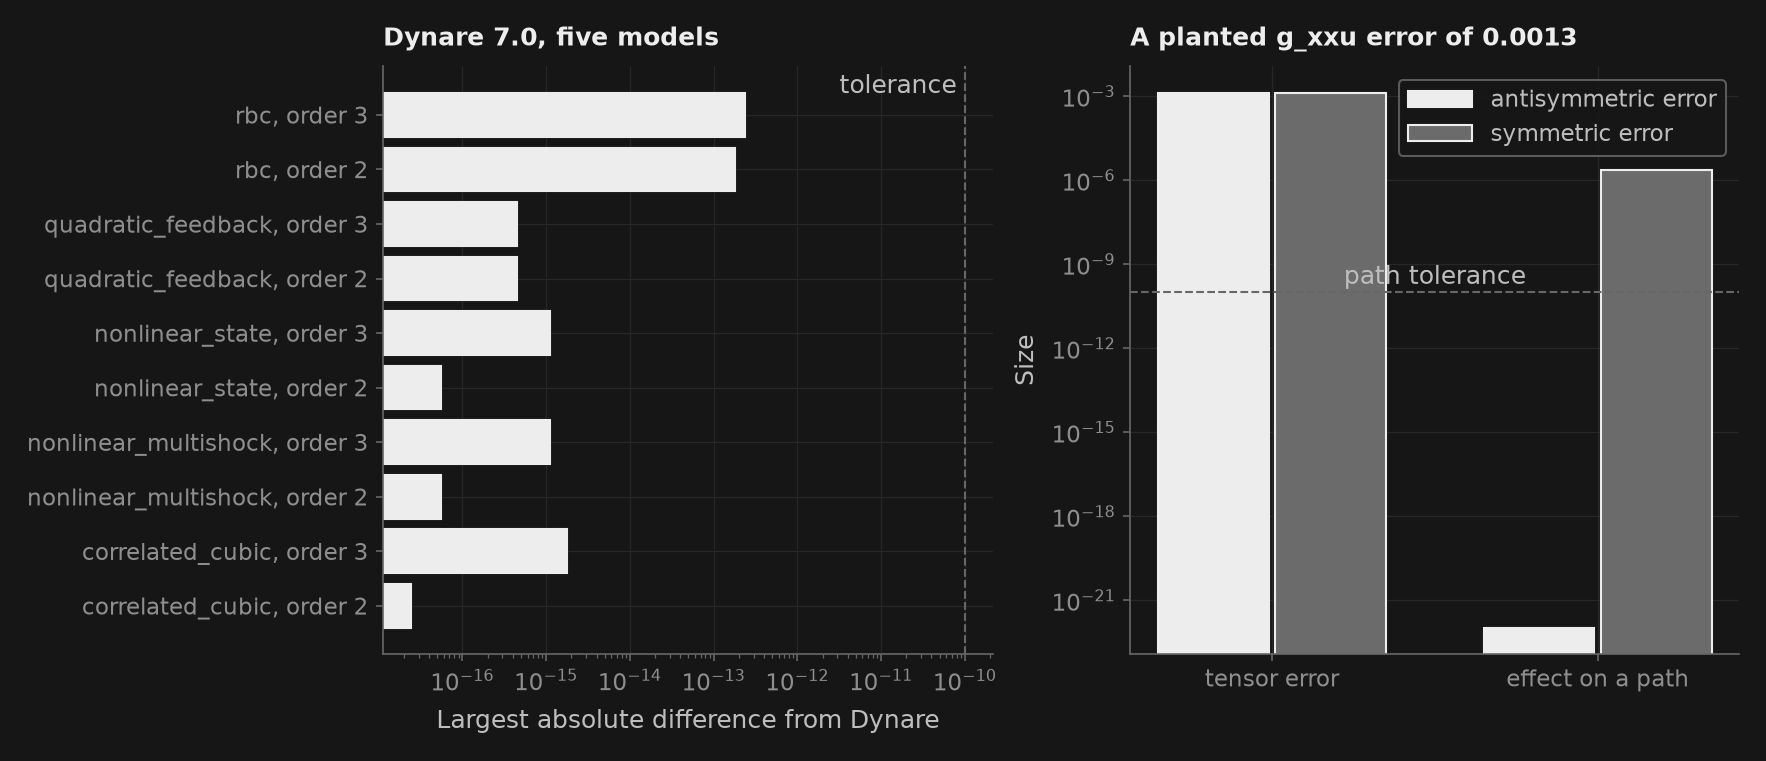

In [5]:
col = _nbstyle.palette(2)
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.5, 4.8))
if dynare is not None:
    worst = dynare[["tensors", "path", "moments"]].max(axis=1).clip(lower=1e-18)
    ax1.barh(range(len(worst)), worst.to_numpy(), color=col[0], edgecolor=_nbstyle.TINTA)
    ax1.set_yticks(range(len(worst)), [c.replace("_order", ", order ") for c in worst.index])
    ax1.axvline(atol, color=_nbstyle.SPINE, lw=1.0, linestyle="--")
    ax1.annotate("tolerance", (atol, len(worst) - 0.6), textcoords="offset points", xytext=(-4, 0), ha="right",
                 color=_nbstyle.TEXTO)
    ax1.set(xscale="log", xlabel="Largest absolute difference from Dynare", title="Dynare 7.0, five models")
else:
    ax1.text(0.5, 0.5, "Dynare fixtures need\nthe repository checkout", ha="center", va="center",
             transform=ax1.transAxes, color=_nbstyle.TEXTO)
    ax1.set_axis_off()
labels = ["tensor error", "effect on a path"]
x = np.arange(2)
for k, name in enumerate(("antisymmetric", "symmetric")):
    values = blind[name].clip(lower=1e-24).to_numpy()
    ax2.bar(x + (k - 0.5) * 0.36, values, width=0.34, color=col[k], edgecolor=_nbstyle.TINTA, label=f"{name} error")
ax2.axhline(1e-10, color=_nbstyle.SPINE, lw=1.0, linestyle="--")
ax2.annotate("path tolerance", (0.5, 1e-10), textcoords="offset points", xytext=(0, 4), ha="center",
             color=_nbstyle.TEXTO)
ax2.set_xticks(x, labels)
ax2.set(yscale="log", ylabel="Size", title="A planted g_xxu error of 0.0013")
ax2.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

### 4. What the checked third order says

In the RBC model, risk shifts the ergodic mean above the deterministic steady state: households hold precautionary capital. That shift is a second-order term and must be proportional to the variance of the shocks. The pruned decomposition gives a sharp simulation check: the first-order part has mean zero, so the mean of the second- and third-order parts estimates the shift with little noise. Responses to large shocks become asymmetric, and third order makes them depend on the level of risk. For the claim to $x^3$, the whole response of the price to small news is a third-order risk effect, $B\,e$, which is proportional to the variance.

In [6]:
def responses(sol, size, horizon, sigma=1.0):
    """Order-1, order-2 and order-3 responses to one shock of `size`, with no further shocks."""
    e = np.zeros((horizon + 1, len(sol.shock_names)))
    e[0, 0] = size
    shocked = sol.simulate(periods=horizon + 1, shocks=e, burn=0, sigma=sigma)
    base = sol.simulate(periods=horizon + 1, shocks=np.zeros_like(e), burn=0, sigma=sigma)
    parts = {1: ["1st"], 2: ["1st", "2nd"], 3: ["1st", "2nd", "3rd"]}
    return {k: sum(pd.concat([getattr(shocked, f"states_{p}"), getattr(shocked, f"controls_{p}")], axis=1)
                   - pd.concat([getattr(base, f"states_{p}"), getattr(base, f"controls_{p}")], axis=1) for p in parts[k])
            for k in parts}


ys = dr.ys
shift = {scale: pd.concat(list(rbc.stochastic_steady_state(sigma=scale).values())) for scale in (1.0, 2.0, 3.0)}
scaling_error = max(abs(shift[m]["k"] / shift[1.0]["k"] / m**2 - 1.0) for m in (2.0, 3.0))
control_variate = {}
for scale in (1.0, 3.0):
    long = rbc.simulate(periods=100_000, seed=7, burn=2_000, sigma=scale)
    higher = pd.concat([long.states_2nd + long.states_3rd, long.controls_2nd + long.controls_3rd], axis=1)["k"].to_numpy()
    batches = higher.reshape(100, -1).mean(axis=1)                     # 100 batch means for the standard error
    control_variate[scale] = (higher.mean(), batches.std(ddof=1) / 10.0)
z_scores = {m: (control_variate[m][0] - shift[m]["k"]) / control_variate[m][1] for m in control_variate}
print("Capital above its steady state (% of the steady state), by shock s.d. multiple: "
      + ", ".join(f"x{m:g} {100 * shift[m]['k'] / ys['k']:.4f}" for m in shift))
print("Simulated minus analytic shift, in standard errors: " + ", ".join(f"x{m:g} {z:+.2f}" for m, z in z_scores.items()))

asymmetry = {}
for n_sd in (3, 10):
    up, down = responses(rbc, 0.01 * n_sd, 40), responses(rbc, -0.01 * n_sd, 40)
    asymmetry[n_sd] = {k: np.max(np.abs(up[k]["y"] + down[k]["y"])) / np.max(np.abs(up[k]["y"])) for k in (1, 2, 3)}
print("Output asymmetry |r(+v) + r(-v)| / |r(+v)|:")
print(pd.DataFrame(asymmetry).rename(index=lambda k: f"order {k}", columns=lambda n: f"{n} s.d. shock")
      .to_string(float_format=lambda v: f"{v:.1e}"))
risk_effect = {m: responses(rbc, 0.01, 40, sigma=m)[3]["c"].iloc[0] for m in (1.0, 5.0)}
print(f"Impact response of consumption at 1x and 5x the volatility: {risk_effect[1.0]:.6e}, {risk_effect[5.0]:.6e}")

volatilities = np.array([0.05, 0.1, 0.15, 0.2, 0.25])
small = 1e-3
slopes = []
for s in volatilities:
    r = responses(claim_to_cube(0.95, 0.8, s), small, 0)
    A, B, _ = cube_closed_form(0.95, 0.8, s)
    slopes.append({"s": s, "order 1": r[1]["y"].iloc[0] / small, "order 2": r[2]["y"].iloc[0] / small,
                   "order 3": r[3]["y"].iloc[0] / small, "closed form B + A e^2": B + A * small**2})
slopes = pd.DataFrame(slopes).set_index("s")
print(slopes.to_string(float_format=lambda v: f"{v:.6e}"))
slope_error = np.max(np.abs(slopes["order 3"] / slopes["closed form B + A e^2"] - 1.0))
record("Risk-adjusted mean proportional to variance: largest |shift(m)/(m^2 shift(1)) - 1|", scaling_error, 1e-9, "exact")
record("Risk-adjusted mean against simulation (control variate), largest |z|", max(abs(z) for z in z_scores.values()), 4.0, "statistical")
record("Claim to x^3: order-3 news response against the closed form (relative)", slope_error, 1e-10, "exact")
assert scaling_error < 1e-9 and max(abs(z) for z in z_scores.values()) < 4.0 and slope_error < 1e-10
assert asymmetry[3][1] < 1e-12 and asymmetry[3][2] > 1e-3
assert np.allclose(slopes[["order 1", "order 2"]], 0.0, atol=1e-14)

Capital above its steady state (% of the steady state), by shock s.d. multiple: x1 0.0785, x2 0.3138, x3 0.7061
Simulated minus analytic shift, in standard errors: x1 +1.41, x3 +1.40
Output asymmetry |r(+v) + r(-v)| / |r(+v)|:
         3 s.d. shock  10 s.d. shock
order 1       0.0e+00        0.0e+00
order 2       3.0e-02        9.5e-02
order 3       3.0e-02        9.5e-02
Impact response of consumption at 1x and 5x the volatility: 5.247545e-03, 5.252147e-03
           order 1       order 2      order 3  closed form B + A e^2
s                                                                   
0.05 -4.166667e-40 -4.166667e-40 4.624416e-02           4.624416e-02
0.10 -4.166667e-40 -4.166667e-40 1.849708e-01           1.849708e-01
0.15 -4.166667e-40 -4.166667e-40 4.161819e-01           4.161819e-01
0.20 -4.166667e-40 -4.166667e-40 7.398773e-01           7.398773e-01
0.25 -4.166667e-40 -4.166667e-40 1.156057e+00           1.156057e+00


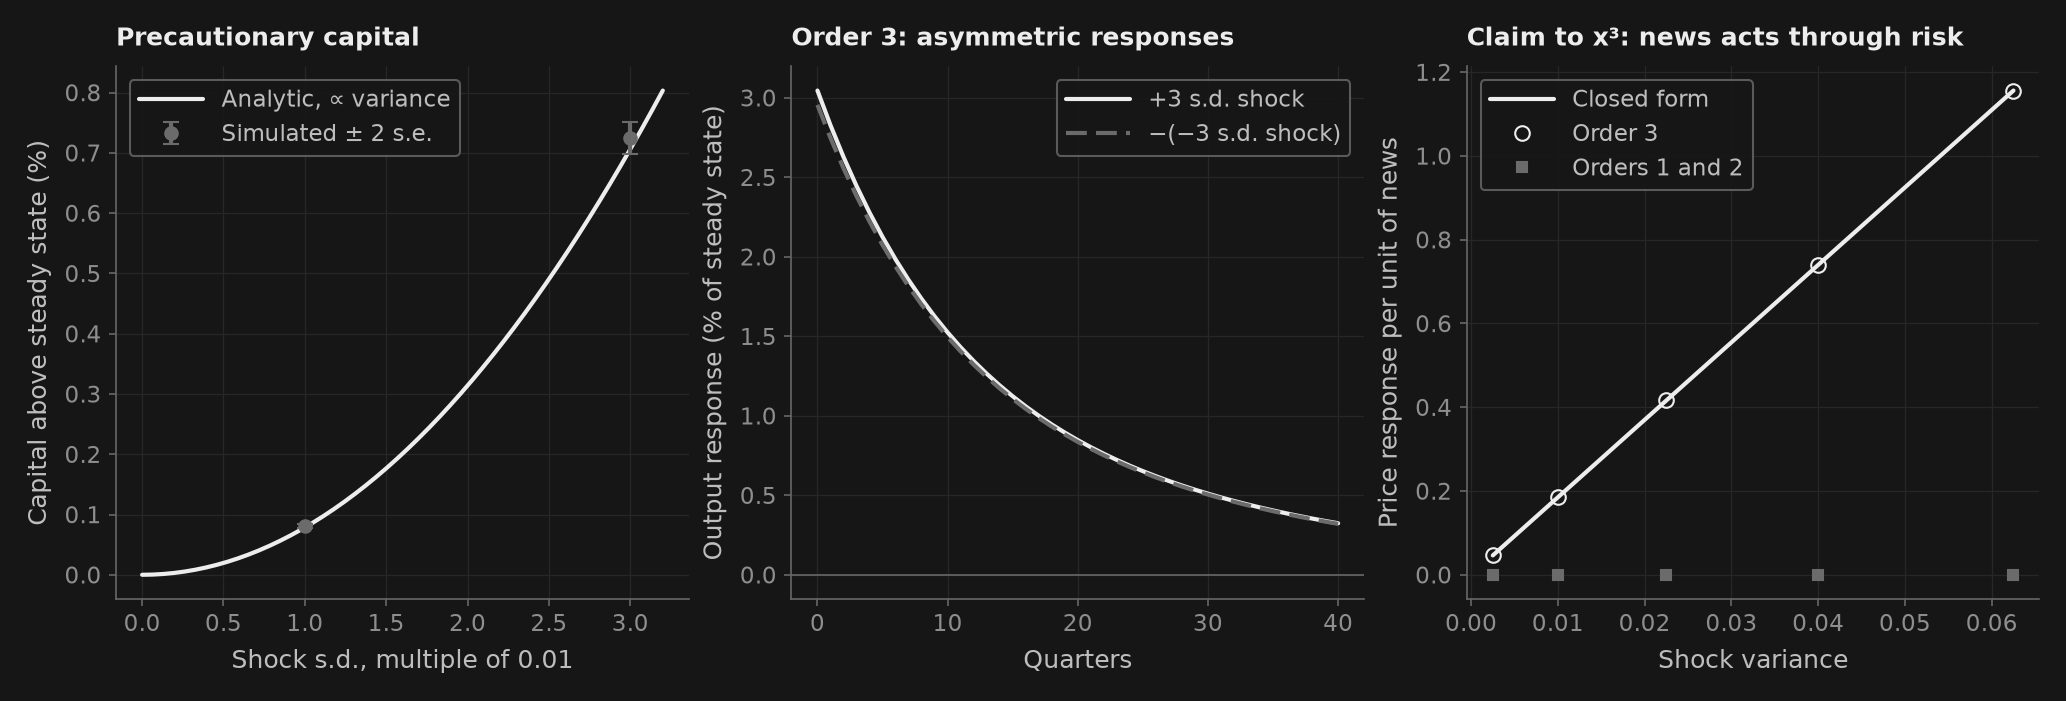

In [7]:
fig, (ax1, ax2, ax3) = _nbstyle.figura(1, 3, figsize=(13.5, 4.4))
grid = np.linspace(0.0, 3.2, 50)
ax1.plot(grid, 100 * shift[1.0]["k"] / ys["k"] * grid**2, color=col[0], lw=2.0, label="Analytic, ∝ variance")
for m, (mean, se) in control_variate.items():
    ax1.errorbar(m, 100 * mean / ys["k"], yerr=200 * se / ys["k"], fmt="o", color=col[1], ms=6, capsize=4,
                 label="Simulated ± 2 s.e." if m == 1.0 else None)
ax1.set(xlabel="Shock s.d., multiple of 0.01", ylabel="Capital above steady state (%)", title="Precautionary capital")
ax1.legend(loc="upper left", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
up, down = responses(rbc, 0.03, 40), responses(rbc, -0.03, 40)
ax2.plot(100 * up[3]["y"] / ys["y"], color=col[0], lw=2.0, label="+3 s.d. shock")
ax2.plot(-100 * down[3]["y"] / ys["y"], color=col[1], lw=2.0, linestyle=_nbstyle.styles(2)[1], label="−(−3 s.d. shock)")
ax2.axhline(0.0, color=_nbstyle.SPINE, lw=0.8)
ax2.set(xlabel="Quarters", ylabel="Output response (% of steady state)", title="Order 3: asymmetric responses")
ax2.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax3.plot(volatilities**2, slopes["closed form B + A e^2"], color=col[0], lw=2.0, label="Closed form")
ax3.plot(volatilities**2, slopes["order 3"], "o", color=col[0], mfc="none", ms=7, label="Order 3")
ax3.plot(volatilities**2, slopes["order 2"], "s", color=col[1], ms=5, label="Orders 1 and 2")
ax3.set(xlabel="Shock variance", ylabel="Price response per unit of news", title="Claim to x³: news acts through risk")
ax3.legend(loc="upper left", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

### 5. Exact moments, and a gap in Dynare's table

The pruned solution is linear in an augmented state, $z_t=[x^{(1)}_t;\,x^{(2)}_t;\,x^{(1)}_t\otimes x^{(1)}_t;\,x^{(3)}_t;\,x^{(1)}_t\otimes x^{(2)}_t;\,x^{(1)}_t\otimes x^{(1)}_t\otimes x^{(1)}_t]$. Its innovations are uncorrelated over time, so `theoretical_moments()` computes the exact mean, covariance and autocorrelations (Andreasen, Fernández-Villaverde and Rubio-Ramírez 2018). Two oracles check them. For the claim to $x^3$, $y=Ax^3+Bx$ with $x$ Gaussian, so Isserlis' theorem gives every moment. With $v=s^2/(1-\rho^2)$ and $r=\rho^k$,
$$\operatorname{Var}(y)=15A^2v^3+6ABv^2+B^2v,\qquad \operatorname{Cov}(y_t,y_{t-k})=A^2v^3(9r+6r^3)+6ABv^2r+B^2vr .$$
The second oracle is Dynare 8's "theoretical moments based on pruned state space", frozen in `tests/fixtures/dynare_order3_pruned_moments.json` for the five live models and the claim. Dynare's means and variances should agree with puremacro to rounding error. Its autocorrelations need not: Dynare's recursion drops the correlation between its innovation $x^{(1)}_{t-1}\otimes u_t\otimes u_t$ and past shocks. The file also holds Dynare's own simulations of four million periods, which say which table is right.

In [8]:
MOMENTS = repo / "tests" / "fixtures" / "dynare_order3_pruned_moments.json"


def cube_moments(beta, rho, s, lags):
    """Variance and autocorrelations of y = A x^3 + B x, by Isserlis' theorem."""
    A, B, _ = cube_closed_form(beta, rho, s)
    v = s**2 / (1.0 - rho**2)
    r = rho ** np.arange(1, lags + 1)
    var = 15 * A**2 * v**3 + 6 * A * B * v**2 + B**2 * v
    return var, (A**2 * v**3 * (9 * r + 6 * r**3) + 6 * A * B * v**2 * r + B**2 * v * r) / var


worst_moment = 0.0
for beta, rho, s in calibrations:
    th = claim_to_cube(beta, rho, s).theoretical_moments(lags=5)
    var, autocorr = cube_moments(beta, rho, s, 5)
    worst_moment = max(worst_moment, abs(th.covariance.loc["y", "y"] / var - 1.0),
                       np.max(np.abs(th.autocorr.loc["y"].to_numpy() - autocorr)))
print(f"Claim to x^3, 12 calibrations: largest error in Var(y) (relative) and five autocorrelations {worst_moment:.1e}")
record("Exact moments: claim to x^3, Var(y) and 5 autocorrelations, 12 calibrations", worst_moment, 1e-12, "exact")
assert worst_moment < 1e-12

acf = None
if MOMENTS.is_file() and LIVE.is_dir():
    frozen = json.loads(MOMENTS.read_text())
    rows, exact_acf = [], {}
    for name, case in frozen["cases"].items():
        text = case.get("model_text") or (LIVE / f"{name}.mod").read_text()
        th = load_mod(text, order=3).theoretical_moments(lags=5)
        names = case["variables"]
        theirs = np.array([np.diag(np.array(m)) for m in case["autocorr"]]).T
        exact_acf[name] = th.autocorr.loc[names]
        rows.append({"model": name, "hash matches": sha256(text.encode()) == case["model_sha256"],
                     "mean": np.max(np.abs(th.moments.loc[names, "Mean"].to_numpy() - case["mean"])),
                     "covariance": np.max(np.abs(th.covariance.loc[names, names].to_numpy() - np.array(case["var"]))),
                     "autocorrelation": np.max(np.abs(exact_acf[name].to_numpy() - theirs))})
    moments_vs_dynare = pd.DataFrame(rows).set_index("model")
    print("\nLargest absolute difference from Dynare 8's pruned moments:")
    print(moments_vs_dynare.to_string(float_format=lambda v: f"{v:.1e}"))
    sim_gap = 0.0
    for name, case in frozen["simulated"]["cases"].items():
        simulated = np.array([np.diag(np.array(m)) for m in case["autocorr"]]).T
        sim_gap = max(sim_gap, np.max(np.abs(simulated - exact_acf[name].loc[case["variables"]].to_numpy())))

    def lagged(case, variable):
        i = case["variables"].index(variable)
        return [m[i][i] for m in case["autocorr"]]

    claim = frozen["cases"]["claim_to_cube"]
    acf = {"claim": pd.DataFrame({"closed form": cube_moments(0.95, 0.8, 0.1, 5)[1],
                                  "puremacro": exact_acf["claim_to_cube"].loc["y"].to_numpy(),
                                  "Dynare's table": lagged(claim, "y")}, index=range(1, 6)),
           "cubic": pd.DataFrame({"Dynare's simulation": lagged(frozen["simulated"]["cases"]["correlated_cubic"], "y"),
                                  "puremacro": exact_acf["correlated_cubic"].loc["y"].to_numpy(),
                                  "Dynare's table": lagged(frozen["cases"]["correlated_cubic"], "y")}, index=range(1, 6))}
    for key, title in (("claim", "Claim to x^3"), ("cubic", "correlated_cubic.mod")):
        print(f"\n{title}: autocorrelation of y by lag")
        print(acf[key].to_string(float_format=lambda v: f"{v:.4f}"))
    print(f"\nDynare's own simulations against puremacro's exact autocorrelations, 3 models: largest gap {sim_gap:.1e}")
    record("Dynare 8 moment fixtures whose model hash differs", (~moments_vs_dynare["hash matches"]).sum(), 0, "provenance")
    record("Dynare 8: pruned means and covariances, 6 models (largest error)",
           moments_vs_dynare[["mean", "covariance"]].to_numpy().max(), 1e-10, "independent")
    record("Dynare 8's own 4e6-period simulations against exact autocorrelations (largest gap)", sim_gap, 3e-3, "statistical")
    assert moments_vs_dynare["hash matches"].all() and moments_vs_dynare[["mean", "covariance"]].to_numpy().max() < 1e-10
    assert sim_gap < 3e-3 and abs(acf["claim"]["Dynare's table"] - acf["claim"]["closed form"]).max() > 0.05
else:
    print("Not run: the Dynare 8 moment fixtures are part of the repository checkout, not of the installed package.")
    for result in ("Dynare 8 moment fixtures whose model hash differs", "Dynare 8: pruned means and covariances, 6 models (largest error)",
                   "Dynare 8's own 4e6-period simulations against exact autocorrelations (largest gap)"):
        record(result, np.nan, "not run", "not run")

Claim to x^3, 12 calibrations: largest error in Var(y) (relative) and five autocorrelations 3.3e-16

Largest absolute difference from Dynare 8's pruned moments:
                      hash matches    mean  covariance  autocorrelation
model                                                                  
correlated_cubic              True 0.0e+00     1.1e-16          1.5e-01
nonlinear_multishock          True 2.1e-17     8.7e-19          2.1e-03
nonlinear_state               True 2.7e-19     1.7e-18          1.8e-03
quadratic_feedback            True 0.0e+00     6.9e-18          9.1e-03
rbc                           True 3.6e-15     1.9e-13          1.9e-05
claim_to_cube                 True 0.0e+00     8.7e-19          7.2e-02

Claim to x^3: autocorrelation of y by lag
   closed form  puremacro  Dynare's table
1       0.7634     0.7634          0.7085
2       0.5920     0.5920          0.5199
3       0.4640     0.4640          0.3919
4       0.3663     0.3663          0.3013
5       0.

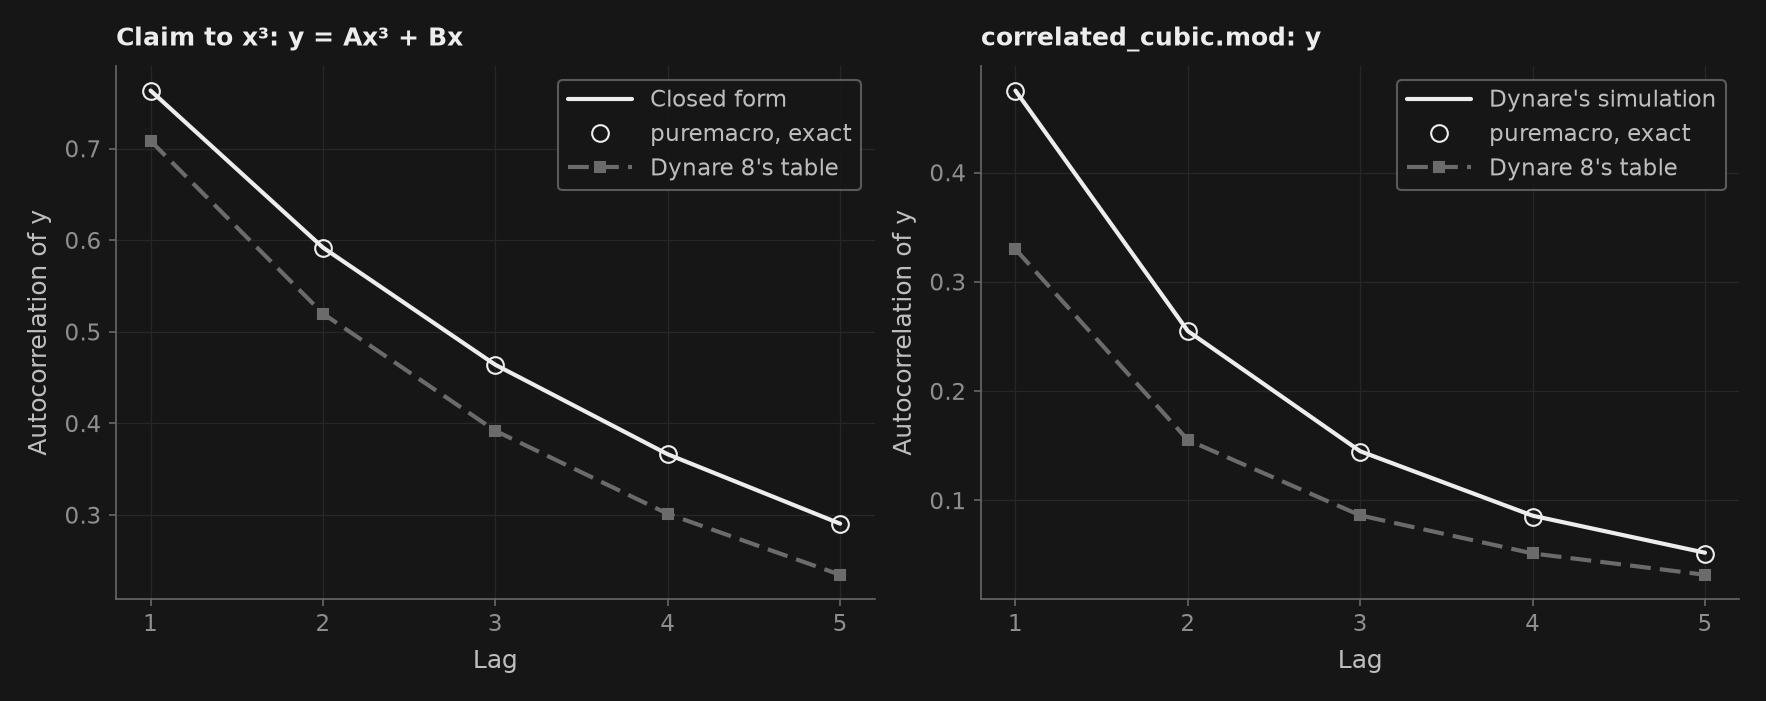

In [9]:
if acf is not None:
    fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.5, 4.4))
    dash = _nbstyle.styles(3)
    for ax, key, reference, title in ((ax1, "claim", "closed form", "Claim to x³: y = Ax³ + Bx"),
                                      (ax2, "cubic", "Dynare's simulation", "correlated_cubic.mod: y")):
        frame = acf[key]
        ax.plot(frame.index, frame[reference], color=col[0], lw=2.0, label=reference.capitalize())
        ax.plot(frame.index, frame["puremacro"], "o", color=col[0], mfc="none", ms=8, label="puremacro, exact")
        ax.plot(frame.index, frame["Dynare's table"], color=col[1], lw=2.0, linestyle=dash[1], marker="s", ms=5,
                label="Dynare 8's table")
        ax.set(xlabel="Lag", ylabel="Autocorrelation of y", title=title, xticks=list(frame.index))
        ax.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

### Replication scorecard

Each row gives the measured value and the bound it had to meet. "Statistical" rows compare with a simulation and use a z-score bound; "not run" appears only when the Dynare fixtures are unavailable. The verdict line is computed from the rows.

In [10]:
scorecard = pd.DataFrame(checks)
print(scorecard.to_string(index=False, formatters={"measured": "{:.1e}".format}))
ran = scorecard[scorecard["verdict"] != "not run"]
assert (ran["measured"] <= ran["bound"].astype(float)).all()
missing = len(scorecard) - len(ran)
print(f"\n{len(ran)} of {len(scorecard)} checks ran and pass" + (f"; {missing} need the repository's Dynare fixtures." if missing
      else ". The third-order solver reproduces both closed forms, Dynare's tensors and paths, and Dynare's pruned means"
              " and variances; its exact autocorrelations match Dynare's own simulations rather than Dynare's table."))

                                                                            result measured        bound     verdict
              Exact oracle: claim to x^3, every tensor, 12 calibrations (relative)  3.3e-16 1.000000e-12       exact
                        Exact oracle: Brock-Mirman policy, every tensor (relative)  8.9e-16 1.000000e-12       exact
                     Exact oracle: Brock-Mirman risk terms (certainty equivalence)  2.2e-18 1.000000e-14       exact
                    Dynare 7.0: fixture files whose hash differs from the manifest  0.0e+00 0.000000e+00  provenance
                                        Dynare 7.0: largest tensor error, 10 cases  1.0e-13 1.000000e-10 independent
                                          Dynare 7.0: largest simulated-path error  2.4e-13 1.000000e-10 independent
                                           Dynare 7.0: largest sample-moment error  9.5e-14 1.000000e-10 independent
                                Blind spot: path effect of the a

## Read the output

Both closed forms are reproduced to rounding error, including the risk terms of the cubic claim, which the table sets beside the values the solver returned before release 4.3.0. Brock and Mirman's model returns risk terms that are zero to rounding, as certainty equivalence of its exact policy requires. Against Dynare, every tensor of every model agrees to the fixtures' tolerance with room to spare, and so do the pruned paths driven by Dynare's own innovations and their sample moments. The references are Dynare's numbers, their hashes match the manifest, and the RBC model used afterwards is the same file Dynare ran.

Section 3 shows why the tensor comparison is the one that matters. The antisymmetric error is as large in the tensor as the symmetric one, but its effect on the simulated path is zero to rounding error; only an entry-by-entry comparison with an independent reference exposes it. That is how the 20 September bug surfaced.

Section 4 is a reminder that a trustworthy solver can report small effects. In this RBC model the precautionary shift in capital is a fraction of a percent at the calibrated volatility and grows with the variance, exactly as the analytic formula says and within sampling error of the simulation. Output responds asymmetrically to large shocks, a second-order effect; third order changes the responses only slightly, and the level of volatility barely moves consumption's impact response. The claim to $x^3$ is the opposite case: at first and second order its price ignores small news, and at third order it responds in proportion to the variance, exactly as the closed form predicts.

Section 5 turns the checks on the moments. Against the closed form of the claim to $x^3$, puremacro's variance and autocorrelations are exact to rounding error, and its means and variances agree with Dynare 8's table on all six models. Dynare's autocorrelations are the exception. For the claim's price its lag-1 autocorrelation is 0.7085, while the closed form gives 0.7634. In `correlated_cubic.mod` Dynare's table gives 0.330, and Dynare's own four-million-period simulation gives 0.475, as puremacro does. A reference implementation can be wrong in one output and right in the rest. Here Dynare's table fails the closed form, and its own simulations reject it too.

## Your turn

Change the claim's discount factor, persistence or volatility; the assertion checks the solver's risk terms against the closed form.

1. **Basic.** Make `rho_claim` negative. Why do both risk terms change sign?
2. **Intermediate.** Move `beta_claim` towards 0.99 with `rho_claim = 0.95`. Which factor of $B$ explains how fast the risk terms grow?
3. **Stretch.** Add a quadratic payoff, `y = beta*y(+1) + x^3 + c2*x^2`. Derive the new closed form (a constant appears) and check which risk term becomes nonzero at second order.

In [11]:
beta_claim = 0.95   # ← change this: discount factor, 0.5 to 0.99
rho_claim = 0.8     # ← change this: persistence of x, -0.95 to 0.95
vol_claim = 0.1     # ← change this: shock standard deviation, 0.01 to 0.5
assert 0.5 <= beta_claim <= 0.99 and -0.95 <= rho_claim <= 0.95 and 0.01 <= vol_claim <= 0.5
_, T = labelled_tensors(claim_to_cube(beta_claim, rho_claim, vol_claim))
A, B, exact = cube_closed_form(beta_claim, rho_claim, vol_claim)
solver = {f: T[f].loc["y"].iloc[0] for f in ("ghxss", "ghuss")}
print(f"B = {B:.6f}; ghxss: solver {solver['ghxss']:.8f}, closed form {exact['ghxss']:.8f}; "
      f"ghuss: solver {solver['ghuss']:.8f}, closed form {exact['ghuss']:.8f}")
assert all(abs(solver[f] - exact[f]) <= 1e-10 * max(1.0, abs(exact[f])) for f in solver)

B = 0.184969; ghxss: solver 0.29595016, closed form 0.29595016; ghuss: solver 0.36993769, closed form 0.36993769


## How comprehensive is this?

Notebooks 00 (release 2.0) and 46 use second-order pruning, and the Spanish course lesson 22 plots third-order responses. `docs/dsge_higher_order.md` documents pruning and responses; the live comparison is `tools/reference_validation/validate_dynare.py`, and regenerating the fixtures needs MATLAB and Dynare. The checks here cover the decision rules, pruned simulation and the exact mean, covariance and autocorrelations. Skewness and kurtosis have no closed form in puremacro: `theoretical_moments()` reports them as NaN, and `ergodic_moments()` estimates them from a simulation. The exact moments need an augmented state of $3n+2n^2+n^3$ entries for $n$ states, so they are limited to about 13 states by default. Epstein-Zin preferences, where third-order terms price risk, are the natural next application.